# Sheet 1b: Continuous Conjugacy — Normal Models, Precision & The Tug-of-War
### *Exact Analytical Updating for Continuous Gaussian Data & Inverse-Variance Weighting*

---

## 🧭 The Learning Progression
* **[Sheet 1: Foundations & Conjugate Updating](01_foundations_and_conjugate_updating.ipynb)**: Analytical updating for **discrete binary data** (Beta-Binomial conjugacy for clicks, conversions, coin flips).
* **👉 Sheet 1b (You are here)**: Analytical updating for **continuous physical measurements** (Normal-Normal conjugacy with known noise $\sigma$).
* **[Sheet 2: Beyond Conjugacy — 2D Grid Approximation](02_frequentist_vs_grid_approximation.ipynb)**: When continuous parameters $(\mu, \sigma)$ are *both* unknown, analytical conjugacy breaks down $\to$ numerical grid approximations.

---

## 🎯 The Core Intuition: The Bayesian "Tug-of-War"

When you update your beliefs using Bayes' Rule, the resulting **Posterior Distribution** represents an optimal compromise between two competing sources:
1. **Your Prior State of Knowledge**: What you believed before collecting data ($p(\mu)$).
2. **Your Observed Evidence / Likelihood**: What your sensors, instruments, or measurements report ($p(y \mid \mu)$).

> **How does Bayes' Rule decide who gets more say in the compromise?**  
> Under a Gaussian (Normal) model, the answer is fundamental to all of data science:  
> $$\textbf{Voting power is inversely proportional to noise (variance).}$$

The source with **smaller noise (higher certainty)** gets the lion's share of the vote, while the source with **larger noise** is discounted.

---

## Part 1: Anatomy of the Weighting Formulas

Let:
* $\mu_0, \sigma_0$: Prior mean and prior standard deviation (prior variance $\sigma_0^2$).
* $y, \sigma$: Observed data measurement and instrument noise standard deviation (measurement variance $\sigma^2$).

### 1.1 What are $w_0$ and $w_L$?
The letter **$w$ stands for "weight"** (influence):
* **$w_0 = \frac{1}{\sigma_0^2}$**: The weight of the **Prior** (subscript $0$ denotes the baseline prior).
* **$w_L = \frac{1}{\sigma^2}$**: The weight of the **Likelihood / Data** ($L$ stands for Likelihood).

*(In classical statistics textbooks, inverse variance $\tau = \frac{1}{\sigma^2}$ is called **precision**. Modern tools like PyMC and Stan parameterize with standard deviation $\sigma$, but the concept is identical: smaller error $\implies$ larger weight).*

### 1.2 What is the $W_{\text{data}}$ Formula?
Just like calculating a student's course grade from Homework ($30\%$) and an Exam ($70\%$):
$$\text{Exam Share} = \frac{\text{Exam Weight}}{\text{Total Weight}}$$

In Bayesian updating, the **total weight** is $w_0 + w_L$. The percentage share of the vote awarded to each source is:
$$W_{\text{data}} = \frac{w_L}{w_0 + w_L} = \frac{\text{Data Weight}}{\text{Total Weight}}$$
$$W_{\text{prior}} = \frac{w_0}{w_0 + w_L} = \frac{\text{Prior Weight}}{\text{Total Weight}}$$

### 1.3 The Posterior Mean Formula: $\mu_{\text{post}}$
The posterior mean is the **weighted average** of the prior mean and the observed data:
$$\mu_{\text{post}} = \frac{w_0 \mu_0 + w_L y}{w_0 + w_L} = W_{\text{prior}} \cdot \mu_0 + W_{\text{data}} \cdot y$$

And the **posterior variance** $\sigma_{\text{post}}^2$ is simply the inverse of the total weight:
$$\sigma_{\text{post}}^2 = \frac{1}{w_0 + w_L} = \frac{1}{\frac{1}{\sigma_0^2} + \frac{1}{\sigma^2}}$$
*(Because $w_0 + w_L > w_0$ and $w_0 + w_L > w_L$, the posterior variance is **always strictly smaller** than both the prior and data variances! Every piece of data reduces uncertainty).*


---

## Part 2: First-Principles Mathematical Derivation

Why does multiplying two Gaussian curves produce this exact weighted average?  
Let us derive it step-by-step from **Bayes' Theorem**:

$$p(\mu \mid y) \propto p(\mu) \times p(y \mid \mu)$$

### Step A: Write the Probability Density Functions
A standard Normal curve centered at mean $m$ with variance $v$ has density:
$$p(x) = \frac{1}{\sqrt{2\pi v}} \exp\left( -\frac{(x - m)^2}{2v} \right) \propto \exp\left( -\frac{1}{2} \cdot \frac{1}{v} \cdot (x - m)^2 \right)$$

Substitute weights $w_0 = \frac{1}{\sigma_0^2}$ and $w_L = \frac{1}{\sigma^2}$:
* **Prior**: $p(\mu) \propto \exp\left( -\frac{1}{2} w_0 (\mu - \mu_0)^2 \right)$
* **Likelihood**: $p(y \mid \mu) \propto \exp\left( -\frac{1}{2} w_L (y - \mu)^2 \right) = \exp\left( -\frac{1}{2} w_L (\mu - y)^2 \right)$

### Step B: Multiply Them (Add the Exponents)
When multiplying exponential functions, their powers add:
$$\text{Exponent} = -\frac{1}{2} \Big[ w_0 (\mu - \mu_0)^2 + w_L (\mu - y)^2 \Big]$$

### Step C: Expand the Quadratic Brackets
$$\begin{aligned}
w_0 (\mu - \mu_0)^2 + w_L (\mu - y)^2 &= w_0 (\mu^2 - 2\mu_0\mu + \mu_0^2) + w_L (\mu^2 - 2y\mu + y^2) \\
&= \mathbf{(w_0 + w_L)}\mu^2 - 2\mathbf{(w_0\mu_0 + w_L y)}\mu + (w_0\mu_0^2 + w_L y^2)
\end{aligned}$$
*(The trailing constant $w_0\mu_0^2 + w_L y^2$ does not depend on $\mu$, so it is absorbed into the normalizing denominator).*

### Step D: Complete the Square
Any Gaussian density centered at an unknown mode $\mu_{\text{post}}$ with precision $C$ matches the template:
$$-\frac{1}{2} C (\mu - \mu_{\text{post}})^2 = -\frac{1}{2} \Big[ C\mu^2 - 2(C \cdot \mu_{\text{post}})\mu + C\mu_{\text{post}}^2 \Big]$$

Matching coefficients:
1. **Coefficient of $\mu^2$**:
   $$C = \mathbf{w_0 + w_L} = \frac{1}{\sigma_0^2} + \frac{1}{\sigma^2} \implies \sigma_{\text{post}}^2 = \frac{1}{C} = \mathbf{\frac{1}{w_0 + w_L}}$$

2. **Coefficient of $-2\mu$**:
   $$C \cdot \mu_{\text{post}} = w_0\mu_0 + w_L y \implies \mu_{\text{post}} = \frac{w_0\mu_0 + w_L y}{C} = \mathbf{\frac{w_0 \mu_0 + w_L y}{w_0 + w_L}} \quad \blacksquare$$


<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
C:\Users\tarob\AppData\Local\Temp\ipykernel_8624\4040219008.py:66: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Parameter $\mu$ (Height cm)", fontsize=10)


=== Analytical Gaussian Updating Calculations ===
Scenario 1: Equal Noise (50/50):
   w_0: 0.0400 (50.0%) | w_L: 0.0400 (50.0%)
   Posterior: N(mu=182.50, sigma=3.54)

Scenario 2: Precise Sensor (Data Wins):
   w_0: 0.0400 (3.8%) | w_L: 1.0000 (96.2%)
   Posterior: N(mu=194.04, sigma=0.98)

Scenario 3: Strong Prior (Prior Wins):
   w_0: 1.0000 (96.2%) | w_L: 0.0400 (3.8%)
   Posterior: N(mu=170.96, sigma=0.98)



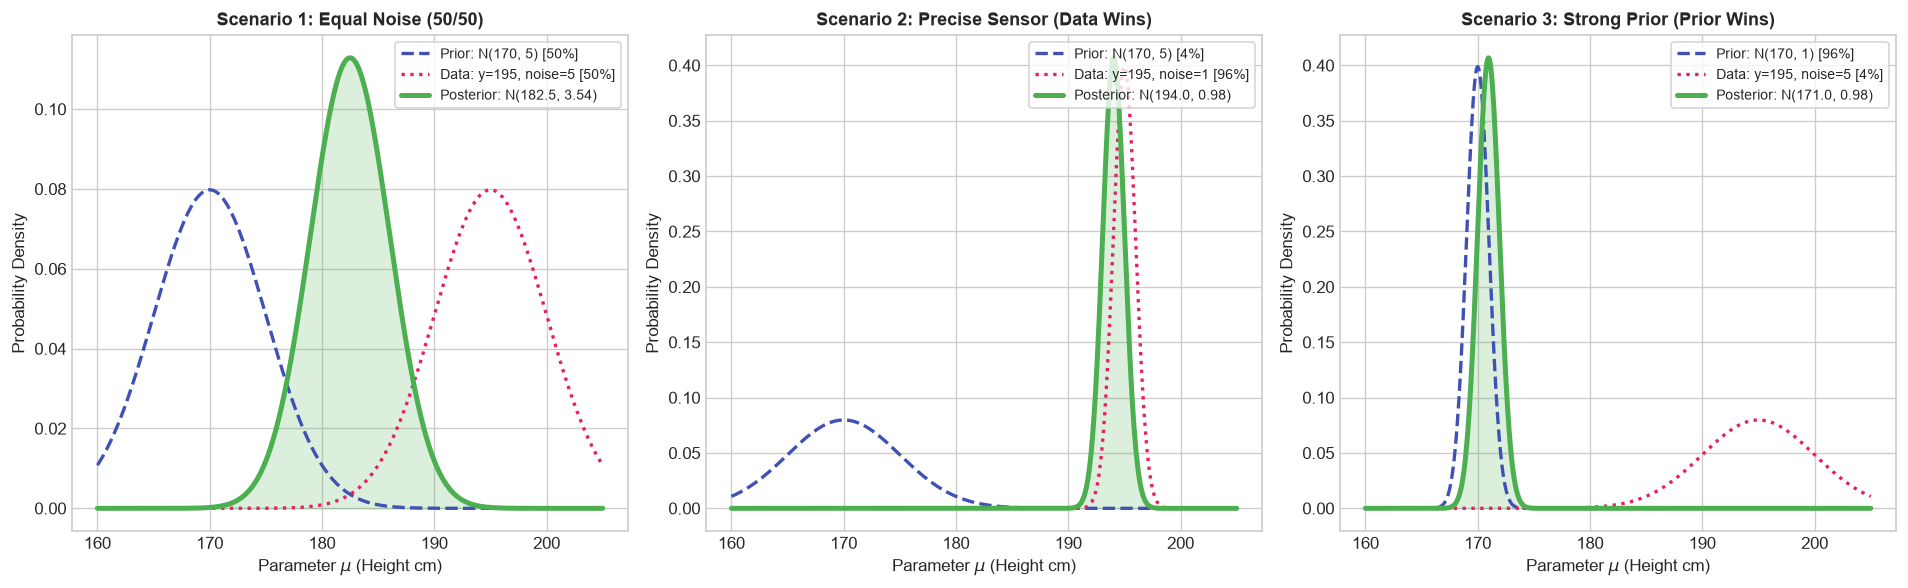

In [1]:
# Part 3: The Three Archetypes Simulation in Python
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)

x = np.linspace(160, 205, 1000)

scenarios = [
    {
        "title": "Scenario 1: Equal Noise (50/50)",
        "mu_0": 170.0, "sigma_0": 5.0,
        "y": 195.0, "sigma": 5.0,
        "ax": axes[0]
    },
    {
        "title": "Scenario 2: Precise Sensor (Data Wins)",
        "mu_0": 170.0, "sigma_0": 5.0,
        "y": 195.0, "sigma": 1.0,
        "ax": axes[1]
    },
    {
        "title": "Scenario 3: Strong Prior (Prior Wins)",
        "mu_0": 170.0, "sigma_0": 1.0,
        "y": 195.0, "sigma": 5.0,
        "ax": axes[2]
    }
]

print("=== Analytical Gaussian Updating Calculations ===")
for sc in scenarios:
    mu_0, s_0 = sc["mu_0"], sc["sigma_0"]
    y, s = sc["y"], sc["sigma"]
    
    # 1. Weights
    w_0 = 1.0 / (s_0**2)
    w_L = 1.0 / (s**2)
    
    # 2. Percentage shares
    W_prior = (w_0 / (w_0 + w_L)) * 100
    W_data  = (w_L / (w_0 + w_L)) * 100
    
    # 3. Posterior parameters
    mu_post = (w_0 * mu_0 + w_L * y) / (w_0 + w_L)
    sigma_post = np.sqrt(1.0 / (w_0 + w_L))
    
    print(f"{sc['title']}:")
    print(f"   w_0: {w_0:.4f} ({W_prior:.1f}%) | w_L: {w_L:.4f} ({W_data:.1f}%)")
    print(f"   Posterior: N(mu={mu_post:.2f}, sigma={sigma_post:.2f})\n")
    
    # Plotting
    ax = sc["ax"]
    p_prior = norm.pdf(x, mu_0, s_0)
    p_lik = norm.pdf(x, y, s)
    p_post = norm.pdf(x, mu_post, sigma_post)
    
    ax.plot(x, p_prior, label=f"Prior: N({mu_0:.0f}, {s_0:.0f}) [{W_prior:.0f}%]", color='#3F51B5', lw=2, linestyle='--')
    ax.plot(x, p_lik, label=f"Data: y={y:.0f}, noise={s:.0f} [{W_data:.0f}%]", color='#E91E63', lw=2, linestyle=':')
    ax.plot(x, p_post, label=f"Posterior: N({mu_post:.1f}, {sigma_post:.2f})", color='#4CAF50', lw=3)
    ax.fill_between(x, p_post, color='#4CAF50', alpha=0.2)
    
    ax.set_title(sc["title"], fontsize=11, fontweight='bold')
    ax.set_xlabel("Parameter $\mu$ (Height cm)", fontsize=10)
    ax.set_ylabel("Probability Density", fontsize=10)
    ax.legend(loc='upper right', fontsize=8.5, frameon=True)

plt.tight_layout()
plt.show()


---

## Part 4: Scaling to $N$ Observations ($n \to \infty$)

When we collect a sample of $n$ observations $y_1, y_2, \dots, y_n$ with sample mean $\bar{y} = \frac{1}{n} \sum y_i$, the joint likelihood exponent sums over all $n$ points:
$$\sum_{i=1}^n -\frac{(y_i - \mu)^2}{2\sigma^2} = -\frac{1}{2} \left( \frac{n}{\sigma^2} \right) (\mu - \bar{y})^2 + \text{const}$$

Notice the data weight is multiplied by $n$:
* **Prior Weight**: $w_0 = \frac{1}{\sigma_0^2}$
* **Collective Data Weight**: $w_L = \mathbf{\frac{n}{\sigma^2}}$

The full updating formula becomes:
$$\mu_{\text{post}} = \frac{\frac{1}{\sigma_0^2}\mu_0 + \frac{n}{\sigma^2}\bar{y}}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}$$

$$\sigma_{\text{post}}^2 = \frac{1}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}$$

### The Inevitable Triumph of Evidence (Bernstein-von Mises Theorem)
As $n \to \infty$, the collective data weight $\frac{n}{\sigma^2}$ grows without bound, while the prior weight $\frac{1}{\sigma_0^2}$ is fixed:
$$\lim_{n \to \infty} W_{\text{data}} = \mathbf{100\%}, \qquad \lim_{n \to \infty} \mu_{\text{post}} = \mathbf{\bar{y}}$$
With large sample sizes in production (e.g., $n = 10,000$), reasonable priors have virtually zero influence on the final posterior mean!


---

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your mathematical intuition with these structured exercises:

---

### 🟢 Tier 1 (Conceptual): Why Variance Governs Weighting Rather Than Standard Deviation
> **Question**: Two independent astronomers measure the speed of an incoming asteroid:
> * Astronomer A uses an optical telescope with measurement error $\sigma_A = 10\text{ km/s}$.
> * Astronomer B uses an uncalibrated radio telescope with error $\sigma_B = 20\text{ km/s}$.
> 
> Does Astronomer A's reading receive $2\times$ as much weight as Astronomer B's, or something else? Explain why variance (squared error) determines voting power in Bayes' rule rather than standard deviation.

In [2]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
sigma_A = 10.0
sigma_B = 20.0

# Calculate the relative weight ratio w_A / w_B:
# weight_ratio = ...

# print(f"Astronomer A gets {weight_ratio:.1f}x the weight of Astronomer B")


<details>
<summary><b>🔍 Click here to view the solution & explanation</b></summary>

**Exact Answer**: Astronomer A receives **$4\times$ as much weight** as Astronomer B (not $2\times$!).

**Mathematical Reason**:
Weights are inversely proportional to **variance** ($\sigma^2$), which is the square of standard deviation:
$$w_A = \frac{1}{\sigma_A^2} = \frac{1}{10^2} = \frac{1}{100} = 0.01$$
$$w_B = \frac{1}{\sigma_B^2} = \frac{1}{20^2} = \frac{1}{400} = 0.0025$$

$$\text{Weight Ratio} = \frac{w_A}{w_B} = \frac{0.01}{0.0025} = \left( \frac{20}{10} \right)^2 = \mathbf{4}$$

Astronomer A carries **$80\%$** of the combined vote ($0.01 / 0.0125$), while Astronomer B carries only **$20\%$**. In Gaussian likelihoods, doubling your instrument's error margin reduces your credibility by a factor of four.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Autonomous Vehicle Sensor Fusion
> **Scenario**: An autonomous vehicle's navigation system is estimating its distance to a pedestrian crossing the street:
> * **Prior Belief (GPS & Dead Reckoning)**: Distance $\mu_0 = 50.0\text{ m}$ with uncertainty $\sigma_0 = 4.0\text{ m}$.
> * **Sensor 1 (Ultrasonic Sonar)**: Measures $y_1 = 44.0\text{ m}$ with noise $\sigma_1 = 3.0\text{ m}$.
> * **Sensor 2 (LIDAR)**: Measures $y_2 = 42.0\text{ m}$ with noise $\sigma_2 = 0.5\text{ m}$.
> 
> Sequentially update the distance estimate:
> 1. Compute the posterior mean and standard deviation after incorporating only the Sonar.
> 2. Compute the final posterior mean and standard deviation after incorporating the LIDAR.


In [3]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
mu_0, sigma_0 = 50.0, 4.0
y_sonar, sigma_sonar = 44.0, 3.0
y_lidar, sigma_lidar = 42.0, 0.5

# Step 1: Update with Sonar
# w_0 = ...
# w_sonar = ...
# mu_step1 = ...
# sigma_step1 = ...

# Step 2: Update with LIDAR
# w_lidar = ...
# mu_final = ...
# sigma_final = ...

# print(f"Distance after Sonar: {mu_step1:.2f} m (+/- {sigma_step1:.2f} m)")
# print(f"Distance after LIDAR: {mu_final:.2f} m (+/- {sigma_final:.2f} m)")


<details>
<summary><b>🔍 Click here to view the solution & code</b></summary>

```python
# Sensor Fusion Execution
mu_0, sigma_0 = 50.0, 4.0
y_sonar, sigma_sonar = 44.0, 3.0
y_lidar, sigma_lidar = 42.0, 0.5

# Step 1: Incorporate Sonar
w_0 = 1.0 / (sigma_0**2)       # 1/16 = 0.0625
w_sonar = 1.0 / (sigma_sonar**2) # 1/9 = 0.1111
mu_step1 = (w_0 * mu_0 + w_sonar * y_sonar) / (w_0 + w_sonar)
sigma_step1 = np.sqrt(1.0 / (w_0 + w_sonar))

# Step 2: Incorporate LIDAR
w_prev = 1.0 / (sigma_step1**2) # w_0 + w_sonar = 0.1736
w_lidar = 1.0 / (sigma_lidar**2) # 1/0.25 = 4.0000
mu_final = (w_prev * mu_step1 + w_lidar * y_lidar) / (w_prev + w_lidar)
sigma_final = np.sqrt(1.0 / (w_prev + w_lidar))

print(f"Prior:          {mu_0:.2f} m (+/- {sigma_0:.2f} m)")
print(f"After Sonar:    {mu_step1:.2f} m (+/- {sigma_step1:.2f} m)")
print(f"After LIDAR:    {mu_final:.2f} m (+/- {sigma_final:.2f} m)")
print(f"LIDAR Voting Share: {(w_lidar / (w_prev + w_lidar))*100:.1f}%")
```

**Output**:
* Distance after Sonar: **$46.16\text{ m}$** ($\pm 2.40\text{ m}$)
* Distance after LIDAR: **$42.17\text{ m}$** ($\pm 0.49\text{ m}$)
* LIDAR carries **$95.8\%$** of the voting share!
</details>

---

### 🔴 Tier 3 (Production Challenge): Proof of Strictly Decreasing Variance
> **Question**: In safety-critical aerospace and medical devices, engineers require guarantees that assimilating sensor data will never *increase* system uncertainty.
> 
> Prove mathematically that under Normal-Normal updating with any non-zero noise $\sigma > 0$, the posterior variance is **strictly smaller** than both the prior variance AND the sensor noise:
> $$\sigma_{\text{post}}^2 < \min(\sigma_0^2, \sigma^2)$$


In [4]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Proof / Verification Here
# ============================================================
# Verify numerically across 1000 random positive pairs (sigma_0, sigma_L):
# sigmas_0 = np.random.uniform(0.1, 100, 1000)
# sigmas_L = np.random.uniform(0.1, 100, 1000)
# sigmas_post = np.sqrt(1.0 / (1.0/sigmas_0**2 + 1.0/sigmas_L**2))
# all_smaller = np.all((sigmas_post < sigmas_0) & (sigmas_post < sigmas_L))
# print(f"Always strictly smaller? {all_smaller}")


<details>
<summary><b>🔍 Click here to view the mathematical proof & code</b></summary>

**Formal Mathematical Proof**:
1. By definition, variance and noise are strictly positive real numbers: $\sigma_0^2 > 0$ and $\sigma^2 > 0$.
2. Consequently, their weights are strictly positive:
   $$w_0 = \frac{1}{\sigma_0^2} > 0 \qquad\text{and}\qquad w_L = \frac{1}{\sigma^2} > 0$$
3. The sum of two positive numbers is strictly greater than either individual summand:
   $$w_0 + w_L > w_0 \qquad\text{and}\qquad w_0 + w_L > w_L$$
4. Inverting both sides of an inequality of positive numbers reverses the inequality:
   $$\frac{1}{w_0 + w_L} < \frac{1}{w_0} = \sigma_0^2$$
   $$\frac{1}{w_0 + w_L} < \frac{1}{w_L} = \sigma^2$$
5. Since $\sigma_{\text{post}}^2 = \frac{1}{w_0 + w_L}$, we have proven:
   $$\sigma_{\text{post}}^2 < \sigma_0^2 \qquad\text{and}\qquad \sigma_{\text{post}}^2 < \sigma^2 \quad \blacksquare$$

**Production Guarantee**: Every valid observation $y$ carries positive information ($w_L > 0$). In Bayesian inference, observing data is mathematically guaranteed to contract the uncertainty bounds of the system.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 1: Beta Distribution & Conjugate Updating](01_foundations_and_conjugate_updating.ipynb) | ⏭️ Next: [Sheet 2: Beyond Conjugacy — Frequentist vs. 2D Grid Approx](02_frequentist_vs_grid_approximation.ipynb)**
